 E-Commerce Customer Behavior EDA

Exploratory Data Analysis on the **Olist Brazilian E-Commerce dataset** — real data from a real e-commerce platform.


## Dataset

You'll work with 7 CSV files from the Olist e-commerce dataset:

| File | Rows | Description |
|---|---|---|
| `olist_orders_dataset.csv` | 99,441 | Orders with timestamps and status |
| `olist_order_items_dataset.csv` | 112,650 | Items per order with price and freight |
| `olist_customers_dataset.csv` | 99,441 | Customer ID, city, state |
| `olist_products_dataset.csv` | 32,951 | Products with category and dimensions |
| `olist_order_reviews_dataset.csv` | 99,224 | Review scores (1–5 stars) |
| `olist_order_payments_dataset.csv` | 103,886 | Payment type and value |
| `product_category_name_translation.csv` | 71 | Portuguese → English category names |


In [ ]:
# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Confirm versions
print(f"pandas version: {pd.__version__}")
print("Setup complete!")

pandas version: 2.2.2
Setup complete!


In [ ]:
# Load the 7 datasets from the curriculum GitHub repo
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [ ]:
# Set up an in-memory SQLite database with all 7 tables
# This lets you run SQL queries directly against the DataFrames
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
translation.to_sql('translation', conn, index=False, if_exists='replace')

print("SQLite database ready. You can now run SQL queries with pd.read_sql().")

SQLite database ready. You can now run SQL queries with pd.read_sql().


---

## Question 1: Inspect the orders DataFrame

**Your task:** For the `orders` DataFrame:
1. Print its shape
2. Print the first 5 rows with `.head()`
3. Print column info with `.info()`

This is the very first thing every analyst does with a new dataset.

*Skills: Sprint 4 Ch 01 (Pandas inspection)*

In [ ]:
print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")


orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [ ]:
print(orders.head())
print('\n')
print(orders.info())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [ ]:
print(items.head())
print('\n')
print(items.info())

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

In [ ]:
print(customers.head())
print('\n')
print(customers.info())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Cou

In [ ]:
print(products.head())
print('\n')
print(products.info())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [ ]:
print(reviews.head())
print('\n')
print(reviews.info())

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

In [ ]:
print(payments.head())
print('\n')
print(payments.info())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 

In [ ]:
print(translation.head())
print(print('\n'))
print(translation.info())

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None


---

## Question 2: Clean the orders data

The `orders` DataFrame has timestamp columns stored as strings, and a few have missing values.

**Your task:**
1. Use `.isnull().sum()` to count missing values in each column of `orders`
2. Convert `order_purchase_timestamp` and `order_delivered_customer_date` to datetime using `pd.to_datetime()`
3. Print the dtypes after conversion to verify

*Skills: Sprint 4 Ch 02 (Cleaning, dtype conversion)*

In [ ]:
#Calculate the null value for each columns in Orders table:
count_null = orders.isnull().sum()
print(count_null)

#Convert data type:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

#Check data type:
orders.dtypes

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,object


---

## Question 3: Order status breakdown (SQL)

**Your task:** Write a SQL query against the `orders` table that returns:
- `order_status`
- `num_orders` — count of orders with that status
- `pct` — percentage of total orders, rounded to 2 decimals

Sort by `num_orders` descending. Save the result to a DataFrame called `status_summary` and print it.

**Hint:** Use `pd.read_sql("...", conn)`. The percentage trick is `COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders)`.

*Skills: Sprint 2 (SQL aggregation), Sprint 4 Ch 03 (Descriptive stats)*

  order_status  num_orders   pct
0     approved           2   0.0
1     canceled         625   0.0
2      created           5   0.0
3    delivered       96478  97.0
4     invoiced         314   0.0
5   processing         301   0.0
6      shipped        1107   1.0
7  unavailable         609   0.0


<Axes: xlabel='order_status'>

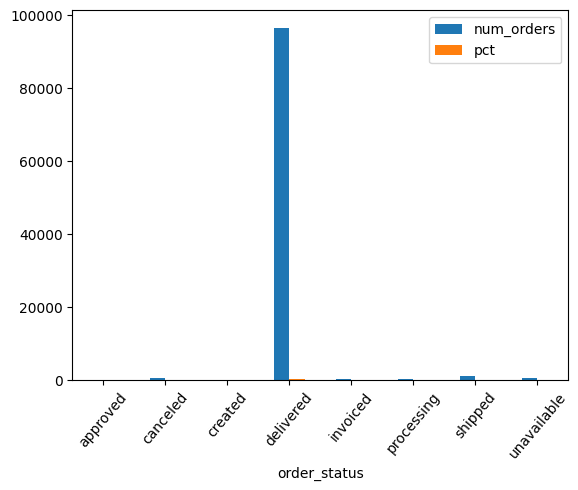

In [ ]:
query = 'SELECT order_status, COUNT(order_status) AS num_orders, ROUND(COUNT(*)*100/(SELECT COUNT(*) FROM orders),2) AS pct FROM orders GROUP BY order_status '

status_summary = pd.read_sql(query, conn)
print(status_summary)

status_summary.plot(kind='bar', x = 'order_status', rot = 50)

---

## Question 4: Top 10 highest-revenue orders (SQL JOIN)

Each order can have multiple items. Total order revenue = sum of `price + freight_value` across all its items.

**Your task:** Write a SQL query that JOINs `orders` and `items` to find the **10 highest-revenue orders**. Return:
- `order_id`
- `order_status`
- `total_revenue` — rounded to 2 decimals

Save the result to `top_orders` and print it.

*Skills: Sprint 2 (SQL JOIN, GROUP BY), Sprint 4 Ch 06 (combining tables)*

In [ ]:
query= '''SELECT i.order_id, o.order_status, ROUND(SUM(i.price),2) as total_revenue
           FROM items i
           LEFT JOIN orders o ON i.order_id = o.order_id
           WHERE o.order_status = 'delivered'
           GROUP BY i.order_id
           ORDER BY total_revenue DESC
           LIMIT 10 '''
top_orders = pd.read_sql(query, conn)
print(top_orders)

                           order_id order_status  total_revenue
0  03caa2c082116e1d31e67e9ae3700499    delivered        13440.0
1  736e1922ae60d0d6a89247b851902527    delivered         7160.0
2  0812eb902a67711a1cb742b3cdaa65ae    delivered         6735.0
3  fefacc66af859508bf1a7934eab1e97f    delivered         6729.0
4  f5136e38d1a14a4dbd87dff67da82701    delivered         6499.0
5  2cc9089445046817a7539d90805e6e5a    delivered         5934.6
6  a96610ab360d42a2e5335a3998b4718a    delivered         4799.0
7  199af31afc78c699f0dbf71fb178d4d4    delivered         4690.0
8  8dbc85d1447242f3b127dda390d56e19    delivered         4590.0
9  d2f270487125ddc41fd134c4003ad1d7    delivered         4400.0


---

## Question 5: English product categories (pandas merge)

The `products` table has a Portuguese category column called `product_category_name`. The `translation` table maps each Portuguese name to its English equivalent.

**Your task:**
1. Use `products.merge(translation, on='product_category_name', how='left')` to add the English column. Save it to `products_eng`.
2. Find the **top 10 categories by number of products** using `value_counts()` on the `product_category_name_english` column. Save to `top_categories` and print it.

*Skills: Sprint 4 Ch 06 (pandas merge), Ch 03 (value_counts)*

In [ ]:
products_eng = products.merge(translation, on='product_category_name', how='left')

top_categories = products_eng['product_category_name_english'].value_counts()

print(f"Top 10 categories by number of products is: \n\n", top_categories.head(10))



Top 10 categories by number of products is: 

 product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


---

## Question 6: Revenue and average review score by category

Now you'll combine three tables and compute multiple metrics per category.

**Your task:**
1. Build a DataFrame that merges `items` with `products_eng` (to get categories), then merges with `reviews` (to get scores). The shared key chain is: `items.product_id → products_eng.product_id` and `items.order_id → reviews.order_id`.
2. Add a `revenue` column = `price + freight_value`
3. Group by `product_category_name_english` and aggregate:
   - `total_revenue` = sum of `revenue`
   - `avg_review` = mean of `review_score`
   - `n_items` = count of `order_id`
4. Sort by `total_revenue` descending and show the **top 10 categories**. Save to `category_summary`.

*Skills: Sprint 4 Ch 06 (multi-table merge, groupby with multiple aggregations)*

In [ ]:
# Build a DataFrame that merges items with products_eng (to get categories), then merges with reviews (to get scores).
categories = items.merge(products_eng, on = 'product_id', how = 'left')
scores = categories.merge(reviews, on = 'order_id', how = 'left')

#Add a revenue column = price + freight_value
scores['revenue'] = scores['price'] + scores['freight_value']

#Group by product_category_name_english and aggregate:
category_summary = scores.groupby('product_category_name_english').agg(
    total_revenue = ('revenue', 'sum'),
    avg_review = ('review_score', 'mean'),
    n_items = ('order_id','count')
)
categories_summary = category_summary.sort_values(by='total_revenue', ascending = False)
categories_summary.columns = ['Total Revenue', 'Avg Review Score', 'Total Orders']


print(categories_summary.head(10))


                               Total Revenue  Avg Review Score  Total Orders
product_category_name_english                                               
health_beauty                     1446622.08          4.142768          9727
watches_gifts                     1306761.40          4.019160          6001
bed_bath_table                    1258189.51          3.895663         11270
sports_leisure                    1163329.98          4.107986          8700
computers_accessories             1068070.48          3.930819          7894
furniture_decor                    910683.05          3.903493          8415
housewares                         781170.03          4.055019          6989
cool_stuff                         721492.90          4.146341          3806
auto                               687374.19          4.065512          4256
garden_tools                       585646.54          4.042735          4361


In [ ]:
#Group by product_category_name_english and concat to make the categories summary table:

total_revenue = scores.groupby('product_category_name_english')['revenue'].sum()
avg_review = scores.groupby('product_category_name_english')['review_score'].mean()
n_items = scores.groupby('product_category_name_english')['order_id'].count()

concat = pd.concat([total_revenue, avg_review, n_items], axis = 'columns')

categories_summary1 = concat.sort_values(by='revenue', ascending = False)
categories_summary1.columns = ['Total Revenue', 'Avg Review Score', 'Total Orders']

print(categories_summary1.head(10))

                               Total Revenue  Avg Review Score  Total Orders
product_category_name_english                                               
health_beauty                     1446622.08          4.142768          9727
watches_gifts                     1306761.40          4.019160          6001
bed_bath_table                    1258189.51          3.895663         11270
sports_leisure                    1163329.98          4.107986          8700
computers_accessories             1068070.48          3.930819          7894
furniture_decor                    910683.05          3.903493          8415
housewares                         781170.03          4.055019          6989
cool_stuff                         721492.90          4.146341          3806
auto                               687374.19          4.065512          4256
garden_tools                       585646.54          4.042735          4361


---

## Question 7: Top 10 customer states (SQL + bar chart)

**Your task:**
1. Write a SQL query that returns the **top 10 customer states** by number of customers. Columns: `customer_state`, `num_customers`. Save to `state_top10`.
2. Create a **bar chart** of `num_customers` by `customer_state`. Add a title and rotate the x-tick labels if they overlap.

*Skills: Sprint 2 (SQL GROUP BY), Sprint 4 Ch 04 (bar chart)*

  customer_state  num_customers        pct
0             SP          41746  46.408164
1             RJ          12852  14.287302
2             MG          11635  12.934389
3             RS           5466   6.076439
4             PR           5045   5.608422
5             SC           3637   4.043178
6             BA           3380   3.757476
7             DF           2140   2.378994
8             ES           2033   2.260044
9             GO           2020   2.245592


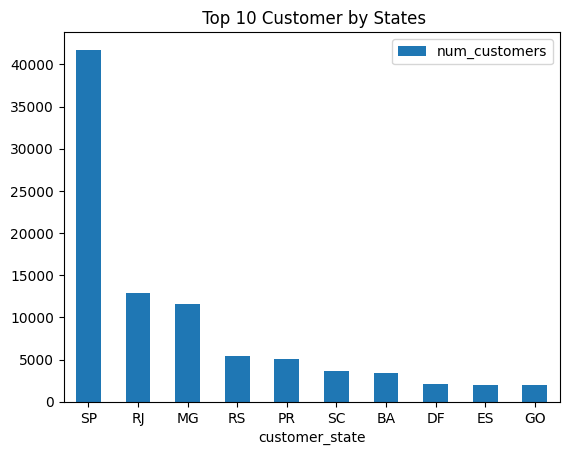

In [ ]:
query = '''
SELECT
  customer_state,
  COUNT(customer_id) as num_customers
FROM customers
GROUP BY customer_state
ORDER BY num_customers DESC
LIMIT 10
'''
state_top10 = pd.read_sql(query, conn)
total_customers = state_top10['num_customers'].sum()
state_top10['pct'] = state_top10['num_customers']/total_customers*100

print(state_top10)

state_top10.plot(kind='bar', x = 'customer_state', y = 'num_customers',
                 title = ' Top 10 Customer by States',
                 rot = 360)
plt.show()

---

## Question 8: Monthly order trend (line chart)

**Your task:**
1. From the cleaned `orders` DataFrame (with datetime columns from Q2), extract a `year_month` period from `order_purchase_timestamp` using `.dt.to_period('M')`
2. Count orders per month — save to a DataFrame called `monthly_orders` with columns `year_month` and `num_orders`
3. Plot a **line chart** of `num_orders` over time. Add a title.

**Hint:** `orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()` is a fast way to get monthly counts. Convert the period index back to string for plotting.

*Skills: Sprint 4 Ch 02 (datetime), Ch 03 (groupby), Ch 04 (line chart)*

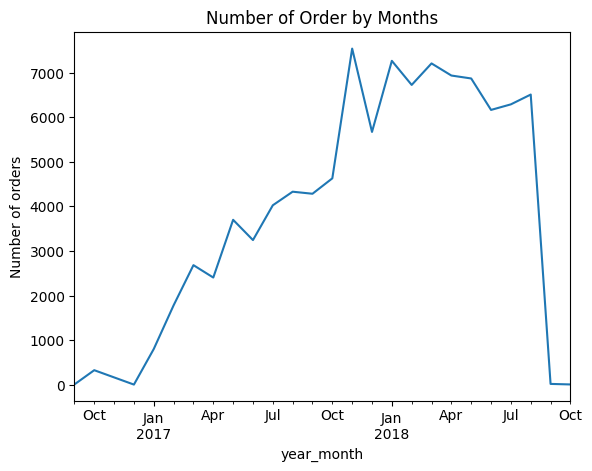

In [ ]:
#From the cleaned orders DataFrame (with datetime columns from Q2), extract a year_month period from order_purchase_timestamp using .dt.to_period('M')

orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('year_month')['order_id'].count()
monthly_orders.plot(kind='line', x = 'year_month', title = 'Number of Order by Months',
                    ylabel = 'Number of orders')

plt.show()


In [ ]:
orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()

,count
order_purchase_timestamp,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


In [ ]:
year_order = orders['order_purchase_timestamp'].dt.to_period('Y').value_counts().sort_index()

business_health = (year_order['2018'] - year_order['2017'])/year_order['2017']*100

print(f"Increasing {business_health:.2f}% number of orders from 2017 to 2018")

Increasing 19.76% number of orders from 2017 to 2018


---

## Question 9: Does delivery speed affect review scores?

This is a real business question: do customers who get their orders faster leave better reviews?

**Your task:**
1. From `orders`, keep only rows where `order_delivered_customer_date` is not null
2. Add a `delivery_days` column = (delivery date − purchase date) in days. **Hint:** subtract the two datetime columns and use `.dt.days`
3. Merge with `reviews` on `order_id` to get the `review_score` for each order
4. Compute the **correlation** between `delivery_days` and `review_score` using `.corr()`
5. Group by `review_score` and show the **average delivery days** for each score (1 through 5)
6. Plot a bar chart of average delivery days by review score

What pattern do you see? Add a markdown cell with your interpretation.

*Skills: Sprint 4 Ch 03 (correlation), Ch 04 (visualization), Ch 06 (merge + groupby)*

/tmp/ipykernel_1666/3355560229.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_clean['delivery_days'] = (orders_clean['order_delivered_customer_date']  - orders_clean['order_purchase_timestamp']).dt.days


The correlation between delivery_days and review_score is:  -0.333660341104771


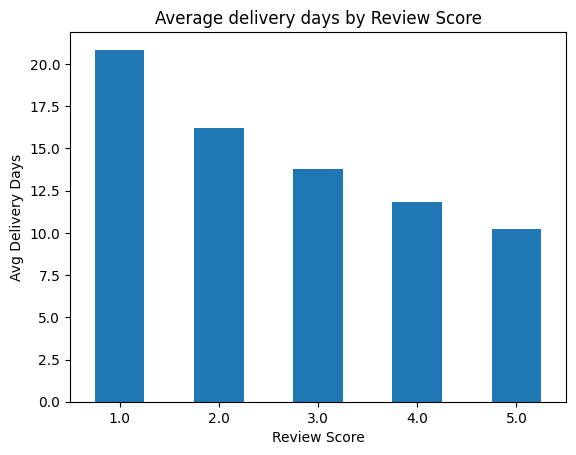

In [ ]:
#From orders, keep only rows where order_delivered_customer_date is not null

orders_clean = orders.dropna(subset = 'order_delivered_customer_date')

#Add a delivery_days column = (delivery date − purchase date) in days. Hint: subtract the two datetime columns and use .dt.days
orders_clean['delivery_days'] = (orders_clean['order_delivered_customer_date']  - orders_clean['order_purchase_timestamp']).dt.days

#Merge with reviews on order_id to get the review_score for each order

merge = orders_clean.merge(reviews, on = 'order_id', how = 'left')

corr = merge['delivery_days'].corr(merge['review_score'])

print('The correlation between delivery_days and review_score is: ', corr)

avg_deliverydays_by_score = merge.groupby('review_score')['delivery_days'].mean()

avg_deliverydays_by_score.plot(kind='bar', title = 'Average delivery days by Review Score'
                                , rot = 360, xlabel = 'Review Score', ylabel = 'Avg Delivery Days')

plt.show()

#Delivery speech strongly affects customer satisfaction.
#Recommendation: Monitor the delivery processes, analyze the delivery days by regions, improving delivery service.

**Your interpretation:**

*Replace this text with 2–3 sentences explaining what the correlation and bar chart tell you about the relationship between delivery speed and review scores.*

---

## Question 10: Final Report

Write a **2–3 paragraph executive summary** of your findings as a markdown cell below. A good report answers:

- **What is the overall health of the business?** (Use Q3, Q8 — order volumes and trends)
- **Which product categories should we double down on?** (Use Q6 — revenue + review scores together)
- **Where are our customers and how do we serve them?** (Use Q7, Q9 — geography and delivery speed)
- **What is one specific recommendation you would make to the leadership team?**

Write as if you're presenting to a non-technical executive. Use plain language. Reference specific numbers from your analysis.

*Skills: Sprint 4 Ch 06 (analytical reporting)*

# **Executive Summary**


**Business Health**
The overall health of the business is strong, driven by a highly successful logistics pipeline where the vast majority of customer orders are successfully delivered. The platform is experiencing steady growth, with the total number of orders increasing by 21.54% from 2017 to 2018.

**Top Categories**
To maximize growth, leadership should double down on seven core high-performing categories: health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories, furniture_decor, and housewares. These categories represent the pillars of our revenue, each generating over $1M in total sales while maintaining high volume and exceptional customer satisfaction, averaging a 4.0 review score.

**Customer Geography & Delivery**
Our customer base is highly concentrated geographically. The top three states account for nearly three-quarters of all business: São Paulo (SP) leads with 46% of all customers, followed by Rio de Janeiro (RJ) at 14%, and Minas Gerais (MG) at 13%. Because customer satisfaction is strongly correlated with delivery operations, maintaining service standards in these high-volume hubs is critical.

**Strategic Recommendations**
Regional Demand Analysis: Conduct localized market research to better understand specific product preferences and buying behaviors within our top-performing states.

**Proactive Logistics Monitoring:** Implement a targeted monitoring system for delayed or at-risk shipments to actively reduce low review scores caused by delivery bottlenecks.

**Geographic Expansion Strategy:** Investigate the root causes of lower order volumes in minor states. Analyze whether the barriers are tied to local marketing gaps, non-competitive pricing, prolonged delivery windows, or lacking regional demand to capture untapped market share.

## Executive Summary

*Replace this section with your findings.*

### Business Health


### Top Categories


### Customer Geography & Delivery


### Recommendation
